In [7]:
import chainladder as cl

In [8]:
tri = cl.load_sample("clrd").groupby("LOB").sum().loc["medmal", "CumPaidLoss"]


# Create a function to grab the scalar tail value.
def scoring(model):
    """Scoring functions must return a scalar"""
    return model.tail_.iloc[0, 0]


# Create a grid of scenarios
param_grid = dict(
    extrap_periods=list(range(1, 1000, 100)),
    curve=["inverse_power", "exponential"]
)

# Fit Grid
model = cl.GridSearch(cl.TailCurve(), param_grid=param_grid, scoring=scoring).fit(tri)

# Plot results
results = model.results_.pivot(columns="curve", index="extrap_periods", values="score")

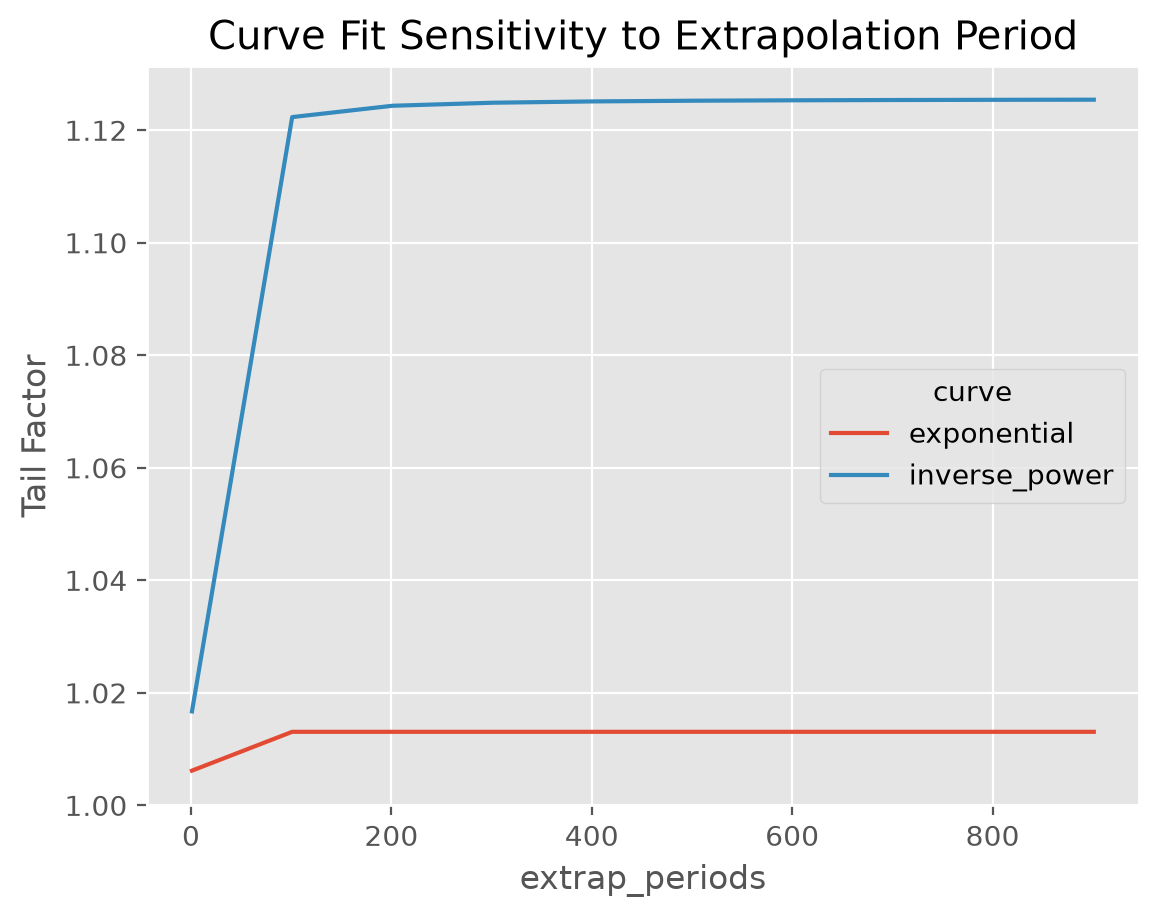

In [ ]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")
%config InlineBackend.figure_format = 'retina'

ax = results.plot(
    ylim=(1, None),
    ylabel="Tail Factor",
    title="Curve Fit Sensitivity to Extrapolation Period",
)




# inverse power pesymista
#exponential optymista 
#extrap_periods mówi, jak daleko w przyszłość szukasz dodatkowych szkód poza końcem trójkąta.
# no ale bez sensu tutaj przesadzać bo nie wiemy co bedzie za 1000 lat 

